In [1]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(cowplot)
library(stringr)
library(scRepertoire)

Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Loading required package: sp

‘SeuratObject’ was built with package ‘Matrix’ 1.7.2 but the current
version is 1.7.3; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”


In [ ]:
pep_rich <- readRDS('../Fig2g_h_VST3/pep_rich_cluster.rds')

In [85]:
phase_summary <- pep_rich@meta.data %>%
    group_by(Phase, Stemness_Concentration) %>%
    summarise(count = n()) %>%
    group_by(Stemness_Concentration) %>%
    mutate(prop = count / sum(count))

`summarise()` has grouped output by 'Phase'. You can override using the
`.groups` argument.


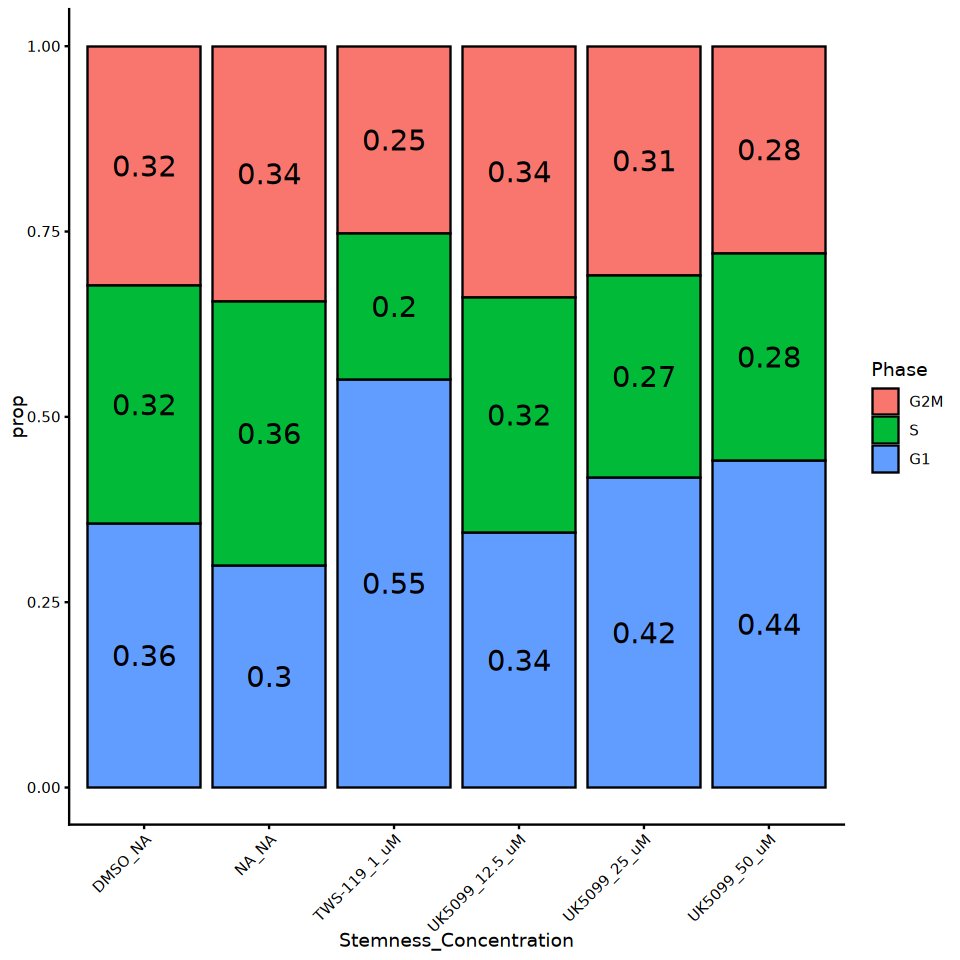

In [86]:
options(repr.plot.width = 8, repr.plot.height = 8)
phase_summary %>%
    mutate(Phase = factor(Phase, levels = c('G2M','S','G1'))) %>%
    ggplot(aes(x=Stemness_Concentration, y=prop, fill = Phase)) + 
    geom_bar(stat='identity', color='black') + 
    geom_text(aes(label = round(prop,2)), size=6,
              position = position_stack(vjust=0.5)) +
    theme_classic() + RotatedAxis()

In [128]:
# Open the PDF graphics device
pdf("plots/SuppFig12_barplot_cell_cycle.pdf", width = 8, height = 8) # You can specify width and height in inches

# Create your plot
phase_summary %>%
    mutate(Phase = factor(Phase, levels = c('G2M','S','G1'))) %>%
    ggplot(aes(x=Stemness_Concentration, y=prop, fill = Phase)) + 
    geom_bar(stat='identity', color='black') + 
    geom_text(aes(label = round(prop,2)), size=6,
              position = position_stack(vjust=0.5)) +
    theme_classic() + RotatedAxis()

# Close the graphics device to save the plot
dev.off()

pdf 
  2